###

![](./assets/both.jpg){ width=40% }

# Introduction

### hi 👋, I'm Alonso {.smaller}

- AI Researcher at Nokia Bell Labs
- PhD at Inria, post-doc at UC Berkeley
- Based in Paris, France
    - Webpage: [https://alonsosilvaallende.github.io/](https://alonsosilvaallende.github.io/)
    - Github: [https://github.com/alonsosilvaallende/](https://github.com/alonsosilvaallende/)
    - Twitter: [@alonsosilva](https://twitter.com/alonsosilva)
    - Bluesky: [https://bsky.app/profile/alonsosilva.bsky.social](https://bsky.app/profile/alonsosilva.bsky.social)
    - Mastodon: [https://sigmoid.social/@alonsosilva](https://sigmoid.social/@alonsosilva)
    - Linkedin: [https://www.linkedin.com/in/alonsosilvaallende/](https://www.linkedin.com/in/alonsosilvaallende/)

###

Slides:

[https://alonsosilvaallende.github.io/2025-PyCon-Chile](https://alonsosilvaallende.github.io/2025-PyCon-Chile)

This presentation:

[https://github.com/alonsosilvaallende/2025-PyCon-Chile/blob/main/PyConChile.ipynb](https://github.com/alonsosilvaallende/2025-PyCon-Chile/blob/main/PyConChile.ipynb)

## Unstructured text &rarr; Structured data

### Application: Extraction

Unstructured text:

> "My name is John Smith and you can contact me at sales@example.com and she is Jane Doe and can be contacted at support@example.com"

&rarr; Structured data:

In [45]:
import pandas as pd

pd.DataFrame({"First name": ["John", "Jane"], "Last name": ["Smith", "Doe"], "email": ["sales@example.com", "support@example.com"]}).style.hide(axis="index")

First name,Last name,email
John,Smith,sales@example.com
Jane,Doe,support@example.com


### Application: Classification

Unstructured text &rarr; Structured data

In [46]:
pd.DataFrame({"Email": ["I would like to have more information related to the new product.", "I cannot exit Vim in my computer. Could you help me with that?", "Are there any openings at your company?"], "Department": ["Sales", "IT", "HR"]}).style.hide(axis="index")

Email,Department
I would like to have more information related to the new product.,Sales
I cannot exit Vim in my computer. Could you help me with that?,IT
Are there any openings at your company?,HR


### Application: Knowledge Graph Generation

Unstructured text:

> "Alice loves Bob but she hates Charles"

&rarr; Structured data:

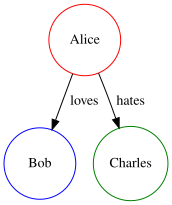

In [44]:
from graphviz import Digraph

dot = Digraph()
dot.node("Alice", shape='circle', color="red", width='1', height='1')
dot.node("Bob", shape='circle', color="blue", width='1', height='1')
dot.node("Charles", shape='circle', color="green", width='1', height='1')
dot.edge(tail_name="Alice", head_name="Bob", label="loves")
dot.edge(tail_name="Alice", head_name="Charles", label="hates")
dot

### Application: Agents / MCP Servers

Unstructured text:

> "What's the temperature in San Francisco now? How about tomorrow?"

&rarr; Structured data:

In [51]:
pd.DataFrame({"Tool": ["get_current_temperature", "get_temperature_by_date"], "Tool arguments": ["{'location': 'San Francisco'}", "{'location': 'San Francisco', 'date': '2025-11-10'}"]}).style.hide(axis="index")

Tool,Tool arguments
get_current_temperature,{'location': 'San Francisco'}
get_temperature_by_date,"{'location': 'San Francisco', 'date': '2025-11-10'}"


## Unstructured text &rarr; Structured data {auto-animate=true}

- 3 ways to go from unstructured text to structured data using language models:
    - Modify the weights (SFT, RLVR, etc.)
    - Improve the prompt (Instructor, DSPy, BAML, etc.)
    - Constrain the generation (Outlines, Xgrammar, Guidance, etc.)

## Unstructured text &rarr; Structured data {auto-animate=true}

- 3 ways to go from unstructured text to structured data using language models:
    - Modify the weights (SFT, RLVR, etc.)
    - Improve the prompt (Instructor, DSPy, BAML, etc.)
    - **Constrain the generation (Outlines, Xgrammar, Guidance, etc.)**

## Unstructured text &rarr; Structured data {auto-animate=true}

- 3 ways to go from unstructured text to structured data using language models:
    - Modify the weights (SFT, RLVR, etc.)
    - Improve the prompt (Instructor, DSPy, BAML, etc.)
    - **Constrain the generation (Outlines, Xgrammar, Guidance, etc.)**

**The three approaches—modifying weights, improving prompts, and constraining generation—are complementary and should NOT be viewed as mutually exclusive.**

## Framework vs Library

- A framework enforces a way of doing things.
- A library tries to do one thing well and gets out of your way.

### New Library: Litelines

Installation:
```{.bash filename="Terminal" code-line-numbers=false}
pip install litelines
```

Documentation:
[https://tinyurl.com/litelines](https://tinyurl.com/litelines)

Getting Started colab notebooks:

[https://tinyurl.com/litelines-hf](https://tinyurl.com/litelines-hf)

License: Apache-2.0

In [2]:
#| echo: false
# !nvidia-smi

In [1]:
#| echo: false
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Using transformers library

### 1. Load a model and its tokenizer

```python
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-1.7B"  # https://huggingface.co/Qwen/Qwen3-1.7B
device = torch.device("cuda")  # "cuda", "cpu" or "mps"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)
```

In [2]:
#| echo: false
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-1.7B"
device = torch.device("cuda")  # "cuda", "cpu" or "mps"
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, 
    cache_dir="/big_storage/llms/hf_models/"
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    cache_dir="/big_storage/llms/hf_models/",
).to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### 2. Prepare the inputs and generate a response

In [3]:
#| echo: true
#| code-line-numbers: 1|2|3-10|11|12-15|16
user_input = "Hello"
messages = [{"role": "user", "content": user_input}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    enable_thinking=False,
    tools=[],
    return_tensors="pt",
    return_dict=True,
).to(model.device)
prompt_length = inputs["input_ids"].shape[-1]
generated = model.generate(
    **inputs, temperature=0.1, logits_processor=[], 
    max_new_tokens=100
)
tokenizer.decode(generated[0][prompt_length:-1])

'Hello! How can I assist you today? 😊'

### 2. Prepare the inputs and generate a response {auto-animate="true"}

```python
user_input = "Hello"
messages = [{"role": "user", "content": user_input}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    enable_thinking=False,
    tools=[],
    return_tensors="pt",
    return_dict=True,
).to(model.device)
prompt_length = inputs["input_ids"].shape[-1]
generated = model.generate(
    **inputs, temperature=0.1, logits_processor=[], 
    max_new_tokens=100
)
tokenizer.decode(generated[0][prompt_length:-1])
```

### 2. Prepare the inputs and generate a response {auto-animate=true}

```python
def generate_response(user_input, tools=[], 
                      logits_processor=[], enable_thinking=False):
    messages = [{"role": "user", "content": user_input}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        enable_thinking=False,
        tools=tools,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)
    prompt_length = inputs["input_ids"].shape[-1]
    generated = model.generate(
        **inputs, temperature=0.1, logits_processor=logits_processor, 
        max_new_tokens=100
    )
    return tokenizer.decode(generated[0][prompt_length:-1])
```

In [4]:
#| echo: false
def generate_response(user_input, 
                      tools=[], 
                      logits_processor=[], enable_thinking=False):
    messages = [{"role": "user", "content": user_input}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        enable_thinking=False,
        tools=tools,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)
    prompt_length = inputs["input_ids"].shape[-1]
    generated = model.generate(
        **inputs, temperature=0.1, logits_processor=logits_processor, max_new_tokens=100
    )
    return tokenizer.decode(generated[0][prompt_length:-1])

### Generate a response

In [5]:
#| echo: true
user_input = "Hello"
generate_response(user_input)

'Hello! How can I assist you today? 😊'

## Generate a streamed response

In [6]:
#| echo: true
#| code-line-numbers: 1-6,18-33
from transformers import TextIteratorStreamer
from threading import Thread

streamer = TextIteratorStreamer(tokenizer, skip_prompt=True)

def generate_streamed_response(user_input, 
                      tools=[], 
                      logits_processor=[], enable_thinking=False):
    messages = [{"role": "user", "content": user_input}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        enable_thinking=False,
        tools=tools,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)
    generation_kwargs = dict(
            inputs,
            streamer=streamer,
            logits_processor=logits_processor,
            max_new_tokens=100,
            temperature=0.1
        )
    thread = Thread(target=model.generate, kwargs=generation_kwargs)
    thread.start()
    assistant_response = ""
    for chunk in streamer:
        clean_chunk = chunk.split("<|im_end|>")[0]
        assistant_response += clean_chunk
        print(clean_chunk, end="")
    thread.join()
    return assistant_response

### Generate a streamed response

In [7]:
#| echo: true
generate_streamed_response("Write an haiku about Chile");

Cielo azul,  
Río cristalino,  
Tierra en silencio.

# Structured generation

## Structured generation

- It consists of masking forbidden tokens (subwords) during the generation.

### Structured generation

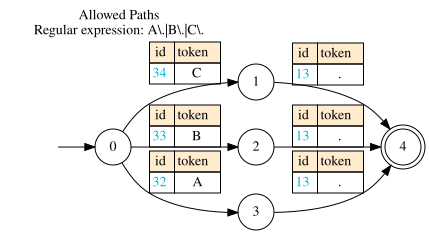

In [34]:
#| echo: true
from litelines.transformers import SchemaProcessor

processor = SchemaProcessor(response_format=r"A\.|B\.|C\.", 
                            tokenizer=tokenizer)
processor.show_graph()

### Structured generation

In [37]:
#| echo: true
user_input = """Which key combination exits Vim?

A) Ctrl+X
B) Esc then :q!
C) Alt+F4

Answer:"""
generate_response(user_input, logits_processor=[processor])

'B.'


. . .


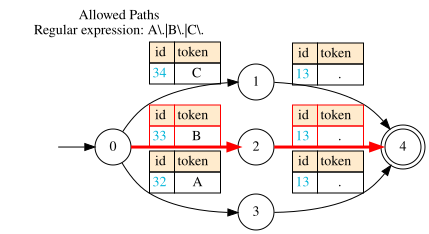

In [38]:
#| echo: true
processor.show_graph()

### Structured generation

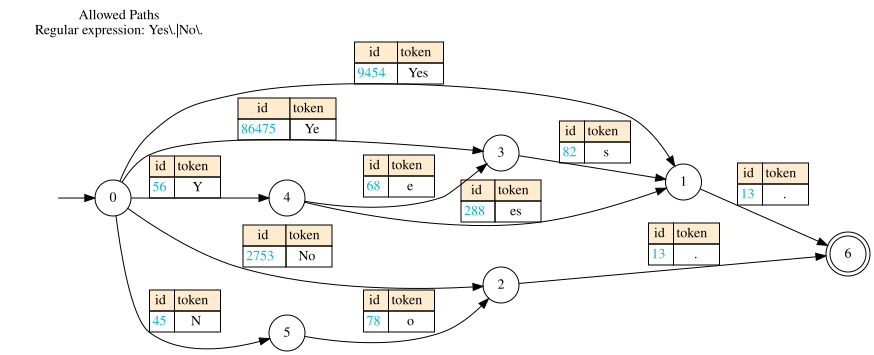

In [13]:
#| echo: true
processor = SchemaProcessor(response_format=r"Yes\.|No\.", 
                            tokenizer=tokenizer)
processor.show_graph()

### Structured generation

In [14]:
#| echo: true
user_input = """Give me an N and an O"""
generate_response(user_input, logits_processor=[processor])

'No.'

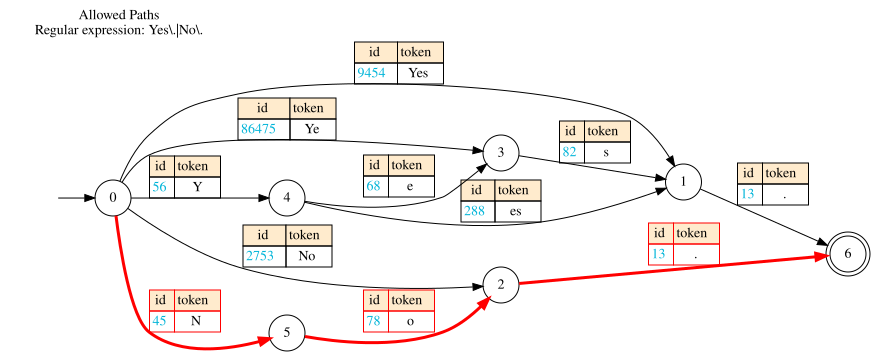

In [15]:
processor.show_graph()

###

[https://molab.marimo.io/notebooks/nb_sbGwmqQdNC5NPQjg7Eu8qi](https://molab.marimo.io/notebooks/nb_sbGwmqQdNC5NPQjg7Eu8qi)

In [16]:
from IPython.display import IFrame


IFrame(f"https://molab.marimo.io/notebooks/nb_sbGwmqQdNC5NPQjg7Eu8qi/app", width=850, sandbox="allow-scripts", height=450)

### Structured generation

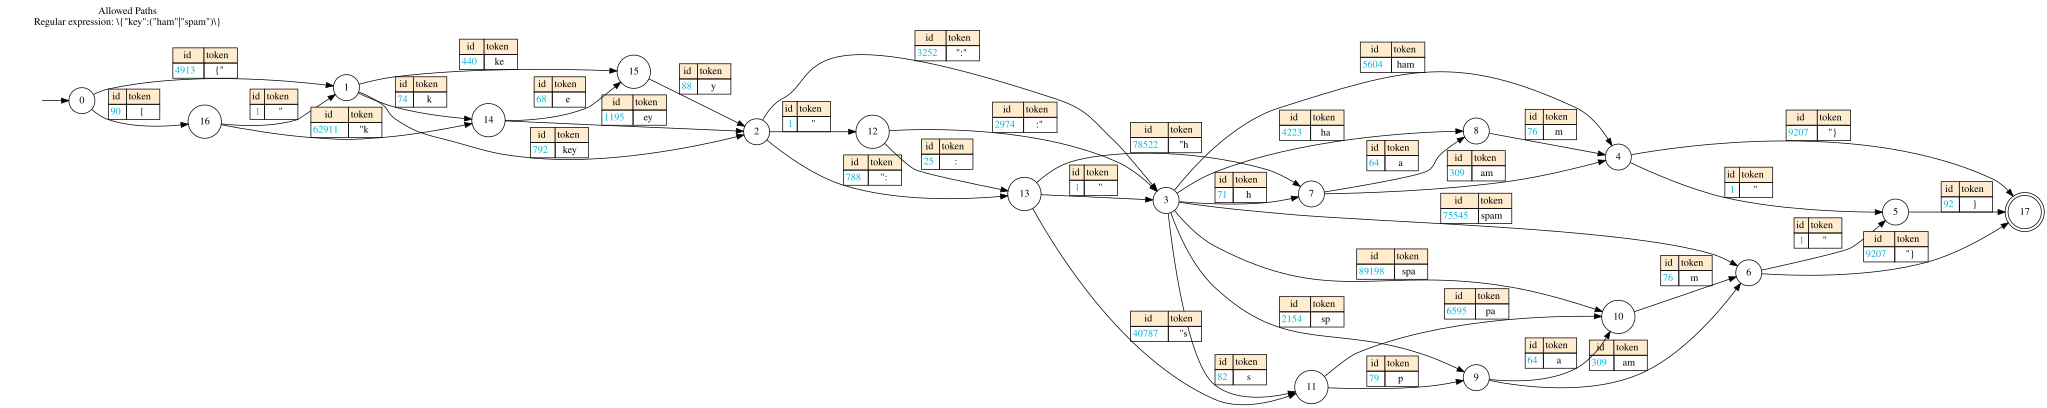

In [43]:
#| echo: true
from pydantic import BaseModel, Field
from typing import Literal

class Sentiment(BaseModel):
    key: Literal["ham", "spam"] = Field(..., description="Is it a spam or a ham")

processor = SchemaProcessor(response_format=Sentiment, tokenizer=tokenizer, whitespace_pattern="")
processor.show_graph()

# Structured outputs

## Structured outputs

- It consists on using the function/tool calling capabilities of language models to structure its response.
- Used by
    - [Instructor](https://python.useinstructor.com/)
    - [Marvin](https://askmarvin.ai/)

### Structured outputs[^1]

In [21]:
#| echo: true
#| code-line-numbers: 1|3-7|9-11|13-14|1-14
user_input = "Extract Jason is 25 years old"

from pydantic import BaseModel, Field

class Person(BaseModel):
    name: str = Field(..., description="The person's name")
    age: int = Field(..., description="The person's age in years")

from openai import pydantic_function_tool

tool = pydantic_function_tool(Person)

assistant_response = generate_response(user_input, tools=[tool])
print(assistant_response)

<tool_call>
{"name": "Person", "arguments": {"name": "Jason", "age": 25}}
</tool_call>


[^1]: Example taken from Hamel Husain's blog post [F*ck You, Show Me The Prompt.](https://hamel.dev/blog/posts/prompt/#instructor)

### Structured outputs

In [23]:
#| echo: true
#| code-line-numbers: 1|3-8|10|11-15|1-15
user_input = "What's the sentiment of the text: That's awesome!"

from typing import Literal

class Sentiment(BaseModel):
    label: Literal["Positive", "Negative"] = Field(
        ..., description="The sentiment conveyed by the text"
    )

tool = pydantic_function_tool(Sentiment)
assistant_response = generate_response(
    user_input, 
    tools=[tool],
)
print(assistant_response)

<tool_call>
{"name": "Sentiment", "arguments": {"label": "Positive"}}
</tool_call>


### Structured outputs sometimes fail

In [24]:
#| echo: true
user_input = "That's awesome!"

from typing import Literal

class Sentiment(BaseModel):
    label: Literal["Positive", "Negative"] = Field(
        ..., description="The sentiment conveyed by the text"
    )

tool = pydantic_function_tool(Sentiment)
assistant_response = generate_response(
    user_input, 
    tools=[tool],
)
print(assistant_response)

The sentiment of the text "That's awesome!" is Positive.


In [32]:
# #| echo: true
# processor = SchemaProcessor(
#     response_format=Sentiment, tokenizer=tokenizer, include_tool_call=True
# )
# processor.show_graph()

# Structured outputs + structured generation

### Structured outputs + structured generation
- No valid reason not to use both structured generation+structured outputs

### Structured outputs + structured generation

In [27]:
#| echo: true
#| code-line-numbers: 9-11,15|1-17
user_input = "That's awesome!"

class Sentiment(BaseModel):
    label: Literal["Positive", "Negative"] = Field(
        ..., description="The sentiment conveyed by the text"
    )

tool = pydantic_function_tool(Sentiment)
processor = SchemaProcessor(
    response_format=Sentiment, tokenizer=tokenizer, include_tool_call=True
)
assistant_response = generate_response(
    user_input, 
    tools=[tool], 
    logits_processor=[processor]
)
print(assistant_response)

<tool_call>
{"name": "Sentiment", "arguments": {"label": "Positive"}}
</tool_call>


### Structured outputs + structured generation

In [45]:
#| echo: true
#| code-line-numbers: 8-10,14|1-16
user_input = "Extract Jason is 25 years old"

class Person(BaseModel):
    name: str = Field(..., description="The person's name")
    age: int = Field(..., description="The person's age in years")

tool = pydantic_function_tool(Person)
processor = SchemaProcessor(
    response_format=Person, tokenizer=tokenizer, include_tool_call=True
)
assistant_response = generate_response(
    user_input, 
    tools=[tool], 
    logits_processor=[processor]
)
print(assistant_response)

<tool_call>
{"name": "Person", "arguments": {"name": "Jason", "age": 25}}
</tool_call>


## Streamed structured outputs+structured generation

In [47]:
#| echo: true
assistant_response = generate_streamed_response(
    user_input, 
    tools=[tool], 
    logits_processor=[processor]
)

<tool_call>
{"name": "Person", "arguments": {"name": "Jason", "age": 25}}
</tool_call>

### Visualize the processor

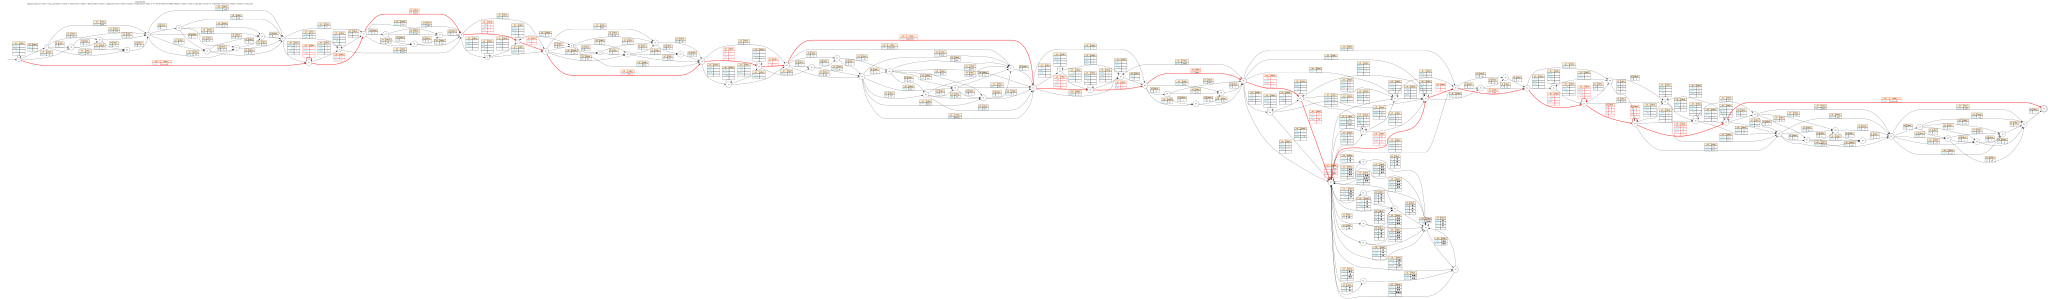

In [46]:
#| echo: true
processor.show_graph()

# Experiments

- SST2 dataset
- Without logits processor/ with logits processor
    - Qwen2.5-0.5B: 78.14% -> 84.17%
    - Qwen2.5-1.5B: 82.57% -> 90.6%

# Conclusions

### Conclusions

- Litelines is a new library to do structured generation
- It allows to easily combine structured generation with structured outputs

### Perspectives

- Do batching with transformers library
- Incorporate vllm
- High-level library similar to Marvin or Instructor